Step 1 → Dataset load karo
Step 2 → EDA (Exploratory Data Analysis) — data samjho
Step 3 → Data Cleaning — missing values, etc
Step 4 → Feature Selection — kaun se columns useful hain
Step 5 → Model banao — Linear Regression
Step 6 → Evaluate karo — R², MAE, RMSE
Step 7 → Predict karo naya price!

In [1]:
from sklearn.datasets import fetch_california_housing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [6]:
data=fetch_california_housing()

In [7]:
df=pd.DataFrame(data.data,columns=data.feature_names)

In [8]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [9]:
df['Price']=data.target

In [10]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


df.shape
df.info()
df.describe()
df.isnull().sum()
Correlation Heatmap
Train-Test Split
Linear Regression Model
Prediction
R², MAE, RMSE
Actual vs Predicted Plot

In [12]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
df.shape

(20640, 9)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [16]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [17]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Text(0.5, 0, 'Price (in $100k)')

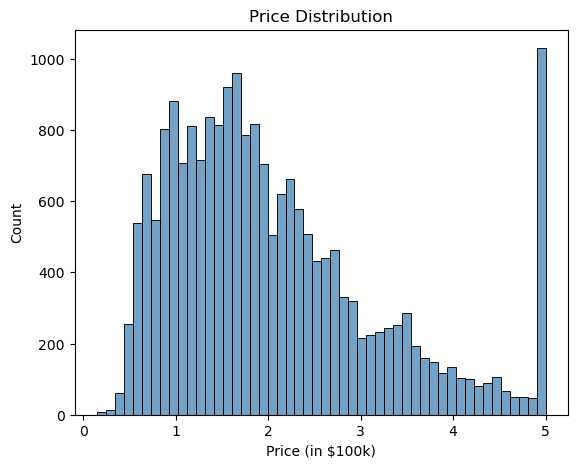

In [23]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(df['Price'],bins=50,color='steelblue')
plt.title('Price Distribution')
plt.xlabel('Price (in $100k)')


Text(0, 0.5, 'Price')

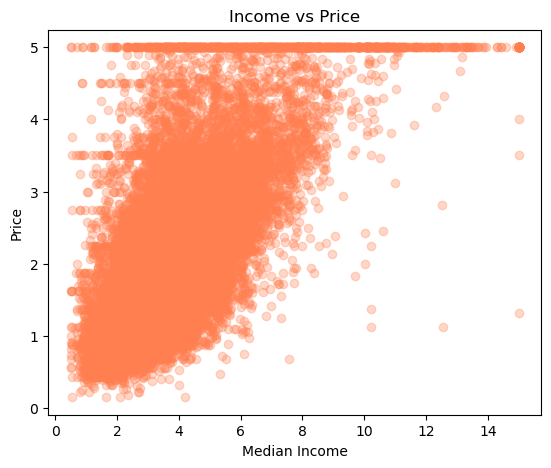

In [27]:
plt.figure(figsize=(14,5))
# plt.subplot(1,2,1)
plt.subplot(1, 2, 2)
plt.scatter(df['MedInc'], df['Price'], alpha=0.3, color='coral')
plt.title('Income vs Price')
plt.xlabel('Median Income')
plt.ylabel('Price')
# plt.tight_layout()
# plt.show()

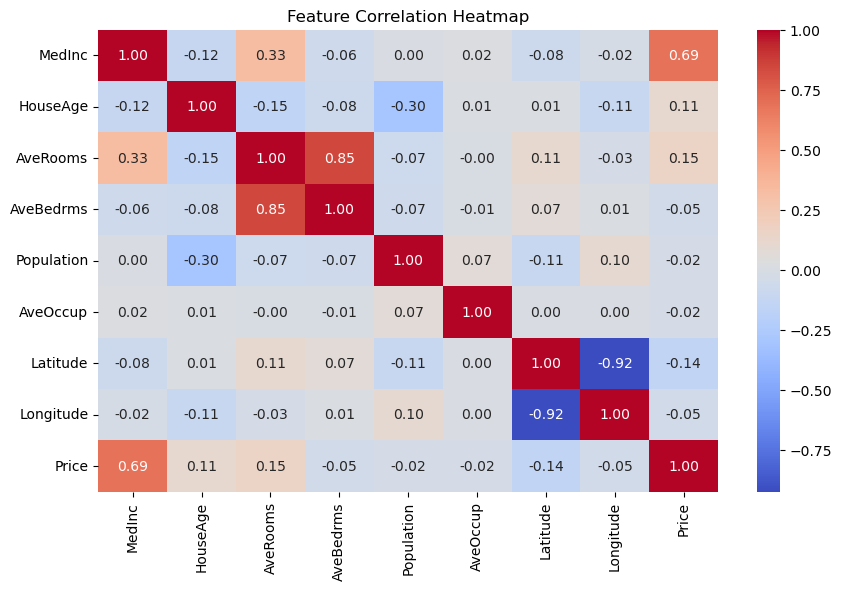

In [28]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [29]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['Price']),df['Price'],test_size=0.2,random_state=42)

In [30]:
lr=LinearRegression()

In [32]:
lr.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
y_pre=lr.predict(X_test)

In [34]:
r2_score(y_test,y_pre)

0.5757877060324512

In [35]:
mean_absolute_error(y_test,y_pre)

0.5332001304956562

In [36]:
mean_squared_error(y_test,y_pre)

0.5558915986952438

In [37]:
np.sqrt(mean_squared_error(y_test,y_pre))

np.float64(0.745581383012776)

In [38]:
sample = [[5.0,20,6.0,1.0,1500,3.0,34.0,-118.0]]

prediction = lr.predict(sample)

print(prediction)

[2.34877058]


D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


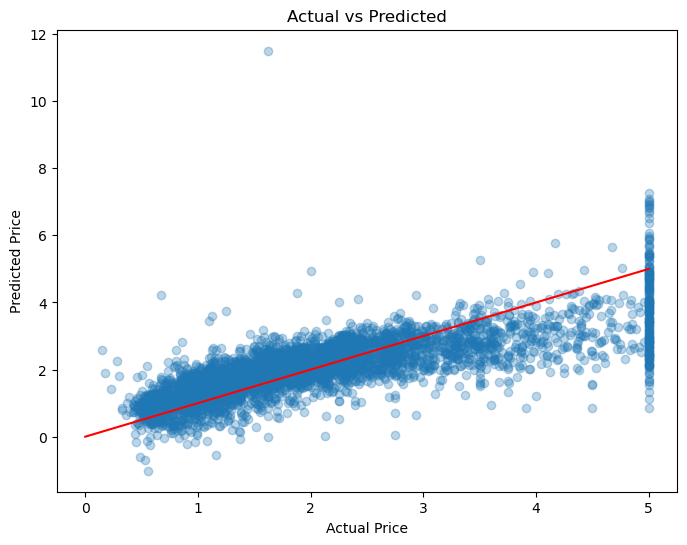

In [41]:
plt.figure(figsize=(8,6))
plt.scatter( y_test , y_pre , alpha=0.3)
plt.plot([0,5],[0,5], color='red')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.show()

<Axes: xlabel='Price', ylabel='Count'>

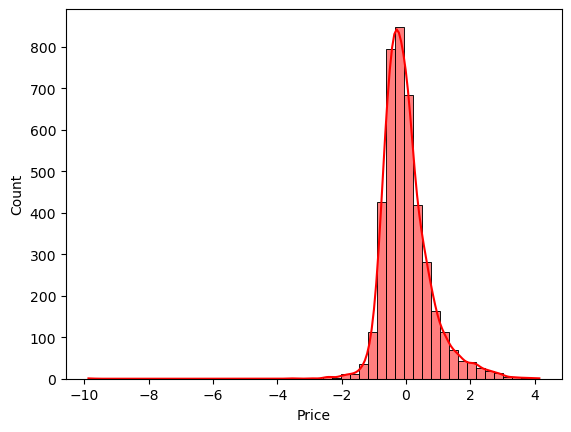

In [44]:
error=y_test-y_pre
sns.histplot(error,bins=50,kde=True,color='red')

In [45]:
new_house = pd.DataFrame({
    'MedInc':[5.0],
    'HouseAge':[20],
    'AveRooms':[6.0],
    'AveBedrms':[1.0],
    'Population':[1500],
    'AveOccup':[3.0],
    'Latitude':[34.0],
    'Longitude':[-118.0]
})

lr.predict(new_house)

array([2.34877058])

In [46]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})

coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


In [49]:
from sklearn.linear_model import Ridge,Lasso

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet

In [52]:
scaler=StandardScaler()

In [63]:
X_train_scaled=scaler.fit_transform(X_train)

In [64]:
X_test_scaled=scaler.transform(X_test)

In [66]:
pd.DataFrame(X_train_scaled, columns=X_train.columns).describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,16512.000000,1.651200e+04,1.651200e+04,1.651200e+04
mean,-6.411753e-17,-1.678244e-17,1.790127e-16,-6.893710e-16,0.000000,1.032766e-17,3.385750e-15,1.776787e-15
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030,1.000030e+00,1.000030e+00,1.000030e+00
min,-1.775438e+00,-2.190766e+00,-1.904386e+00,-1.762117e+00,-1.251913,-2.076846e-01,-1.447697e+00,-2.377207e+00
25%,-6.900689e-01,-8.417859e-01,-4.118373e-01,-2.081645e-01,-0.560634,-5.770769e-02,-8.018107e-01,-1.110749e+00
50%,-1.758995e-01,3.108328e-02,-8.350905e-02,-1.094160e-01,-0.228186,-2.415892e-02,-6.473597e-01,5.346501e-01
75%,4.686502e-01,6.658972e-01,2.621376e-01,8.455177e-03,0.263449,1.580865e-02,9.720351e-01,7.839530e-01
max,5.839268e+00,1.856173e+00,5.716655e+01,5.664727e+01,30.127428,1.071164e+02,2.951816e+00,2.628794e+00


In [79]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

In [80]:
param_grid = {
    'ridge__alpha': [0.001,0.01,0.1,1,10,100]
}

In [81]:
grid=GridSearchCV(pipeline,param_grid,cv=5,scoring='r2')

In [82]:
grid.fit(X_train,y_train)

,estimator,"Pipeline(step...e', Ridge())])"
,param_grid,"{'ridge__alpha': [0.001, 0.01, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [83]:
grid.best_params_

{'ridge__alpha': 0.001}

In [87]:
grid.best_score_

np.float64(0.6114839949716276)

In [88]:
grid.best_estimator_

,steps,"[('scaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,0.001
,fit_intercept,True
,copy_X,True
,max_iter,None


In [91]:
r2_score(y_test, grid.best_estimator_.predict(X_test))

0.5757877341612515

In [92]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

In [98]:
param_grid = {
    'lasso__alpha': [0.001,0.01,0.1,1,10,100]
}

In [99]:
grid=GridSearchCV(pipeline,param_grid,cv=5,scoring='r2')

In [100]:
grid.fit(X_train,y_train)

,estimator,"Pipeline(step...o', Lasso())])"
,param_grid,"{'lasso__alpha': [0.001, 0.01, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [104]:
grid.best_score_

np.float64(0.6114865376489419)

In [105]:
grid.best_params_

{'lasso__alpha': 0.001}

In [106]:
r2_score(y_test, grid.best_estimator_.predict(X_test))

0.5768562568705682

In [111]:
pipeline=Pipeline([
    ('scaler', StandardScaler()),
    ('elastic', ElasticNet(max_iter=1000))
])

In [115]:
param_grid = {
    'elastic__alpha' : [0.001,0.01,0.1,1,10],
    'elastic__l1_ratio' : [0.1,0.3,0.5,0.7,0.9]
}

In [116]:
grid=GridSearchCV(pipeline,param_grid,cv=5,scoring='r2')

In [117]:
grid.fit(X_train,y_train)

,estimator,Pipeline(step...lasticNet())])
,param_grid,"{'elastic__alpha': [0.001, 0.01, ...], 'elastic__l1_ratio': [0.1, 0.3, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [118]:
grid.best_params_

{'elastic__alpha': 0.001, 'elastic__l1_ratio': 0.9}

In [119]:
grid.best_score_

np.float64(0.6114857546927948)

In [120]:
r2_score(y_test,grid.best_estimator_.predict(X_test))

0.5767935612793467